# Rozwiązywanie równań nieliniowych metodą Newtona-Raphsona oraz metodą siecznych

## Dane:
Moja funkcja to:   
$$
    f(x) = mxe^{-n} - me^{-nx} + \frac{1}{m}, x \in [a, b] \\[2ex] n = 10, m = 17, a = -0.4, b = 1.0
$$
Co daje:
$$
    f(x) = 17xe^{-10} - 17e^{-10x}+\frac{1}{17} \\[2ex]
    f'(x) = 170e^{-10x} + 17e^{-10}
$$


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

M, N = 17, 10
A, B = -0.4, 1.0

# Rozwiązanie wyliczone kalkulatorem Wolfram Alpha
SOLUTION = 0.5659029143251876753013761073043433277

def f(x):
    return M * x * np.exp(-N) - M * np.exp(-N * x) + 1/M

def df(x):
    return M * np.exp(-N) + M * N * np.exp(-N * x)

## Metoda Newtona-Raphsona
Dla tej metody musimy wybrać jeden punkt początkowy, a następnie będziemy na jego podstawie stosować wzór iteracyjny z wykładu. Jako punkty początkowe wybieramy kolejno:

$$
    x_0 = 1.0, 0.9, 0.8, \dots, -0.3, -0.4
$$

Wzór iteracyjny:

$$
    x_{i+1} = x_i - \frac{f(x_i)}{f'(x_i)}
$$

Zatrzymujemy iterowanie gdy osiągniemy kryterium stopu, których wyróżniamy trzy w ramach naszego rozwiązania. Poniżej znajdują się pierwsze dwa, nazywane kolejno przyrostowym oraz residualnym:

1.  Przyrostowe: $|x_{i+1} - x_i| < \rho$
2.  Residualne: $|f(x_i)| < \rho$

W ramach dodatkowego zabezpieczenia przed rozbieżnym cyklem musimy również wprowadzić kryterium maksymalnej iteracji, czyli liczby iteracji, której nie możemy przekroczyć.

W celu zbadania zbieżności zapisujemy wszystkie pośrednie $x_i$.

### Na co należy uważać?
Możliwe problemy przy płaskich miejscach, czyli takich, gdzie $f'(x) \approx 0$,
ponieważ wtedy wyskakujemy poza przedział z naszym $x_{i+1}$. Drugim problemem wynikającym z płaskości jest płaskość przy samej osi OX. Możemy przedwcześnie skończyć poszukiwanie miejsca zerowego, gdyż spełnimy kryterium $|f(x_i)| < \rho$.

**Uwaga:** funkcja $f$ nie spełnia jednego z warunków "twierdzenia o wyborze przedziału dla N-R" z wykładu:

$$
\left| \frac{f(1)}{f'(1)} \right| \approx 7 \not < (1 - (-0.4)) = 1.4
$$

Konsekwencją tego jest brak gwarantowanej zbieżności metody Newtona-Raphsona.

In [6]:
def newton_raphson(x0, rho, stop_criterion, max_iter=100):
    history = [x0]
    x_curr = x0
    
    for _ in range(max_iter):
        fx = f(x_curr)
        dfx = df(x_curr)
        
        # Zabezpieczenie przed dzieleniem przez zero 
        if abs(dfx) < 1e-15:
            return None, history, "Błąd: f'(x) bliskie 0"
            
        # Główny wzór iteracyjny
        x_next = x_curr - fx / dfx
        history.append(x_next)
        
        # Sprawdzanie kryterium stopu
        converged = False
        if stop_criterion == "incremental":
            if abs(x_next - x_curr) < rho:
                converged = True
        elif stop_criterion == "residual":
            if abs(f(x_next)) < rho:
                converged = True
                
        if converged:
            return x_next, history, "Sukces"
        
        x_curr = x_next
        
    return x_curr, history, "Osiągnięto limit iteracji"

In [9]:
# Konfiguracja eksperymentu
x0_values = np.round(np.arange(1.0, -0.5, -0.1), 1)
rho_values = [1e-3, 1e-6, 1e-9]
criteria = ["incremental", "residual"]

all_results = []

for rho in rho_values:
    for x0 in x0_values:
        for crit in criteria:
            root, hist, status = newton_raphson(x0, rho, crit)
            
            final_error = abs(root - SOLUTION) if root is not None else None
            
            all_results.append({
                "Metoda": "Newton-Raphson",
                "x0": x0,
                "Rho": rho,
                "Kryterium": crit,
                "Wyznaczony_Pierwiastek": root,
                "Liczba_Iteracji": len(hist) - 1,
                "Blad_Bezwzgledny": final_error,
                "Status": status
            })

df_newton = pd.DataFrame(all_results)
df_newton.to_csv("wyniki_newton_raphson.csv", index=False, sep=';', encoding='utf-8-sig')

print("Eksperyment zakończony. Dane zapisano do 'wyniki_newton_raphson.csv'.")
df_newton.head()

Eksperyment zakończony. Dane zapisano do 'wyniki_newton_raphson.csv'.


,Metoda,x0,Rho,Kryterium,Wyznaczony_Pierwiastek,Liczba_Iteracji,Blad_Bezwzgledny,Status
0,Newton-Raphson,1.0,0.001,incremental,0.565902,69,9.865042e-07,Sukces
1,Newton-Raphson,1.0,0.001,residual,0.565458,68,4.448030e-04,Sukces
2,Newton-Raphson,0.9,0.001,incremental,0.565900,27,2.436703e-06,Sukces
3,Newton-Raphson,0.9,0.001,residual,0.565204,26,6.993633e-04,Sukces
4,Newton-Raphson,0.8,0.001,incremental,0.565902,11,1.066417e-06,Sukces


## Metoda Siecznych
W tej metodzie nie musimy znać pochodnej funkcji $f'(x)$. Zamiast niej stosujemy iloraz różnicowy obliczany z dwóch poprzednich punktów.

### Punkty startowe
Dla każdego eksperymentu musimy wybrać dwa punkty startowe $x_0$ oraz $x_1$:
* Pierwszy punkt ($x_0$): dobieramy tak samo jak w metodzie Newtona ($1.0, \dots, -0.4$).
* Drugi punkt ($x_1$): wybieramy jako jeden z końców przedziału, czyli raz $x_1 = a = -0.4$, a w drugim wariancie $x_1 = b = 1.0$.

### Wzór iteracyjny
$$
    x_{i+2} = x_{i+1} - \frac{x_{i+1} - x_i}{f(x_{i+1}) - f(x_i)} \cdot f(x_{i+1})
$$

### Kryteria stopu
Stosujemy te same trzy kryteria co w metodzie Newtona, aby umożliwić rzetelne porównanie wyników:
1.  Przyrostowe: $|x_{i+1} - x_i| < \rho$
2.  Residualne: $|f(x_i)| < \rho$
3.  Maksymalna liczba iteracji: limit kroków zabezpieczający przed nieskończoną pętlą w przypadku braku zbieżności.

### Charakterystyka metody
* Rząd zbieżności: wynosi ok. **1.62**. Jest to zbieżność szybsza niż liniowa, ale wolniejsza niż kwadratowa (Newtona).
* Zaleta: brak konieczności wyliczania pochodnej analitycznej funkcji.

### Na co należy uważać?
* Dzielenie przez zero: jeśli $f(x_{i+1}) = f(x_i)$, mianownik we wzorze wyzeruje się, co uniemożliwi dalsze obliczenia.
* Brak stabilności przedziału: metoda nie gwarantuje, że pierwiastek będzie znajdował się zawsze pomiędzy punktami $x_i$ a $x_{i+1}$, co może wyprowadzić iteracje poza badany zakres.
* Wpływ punktu startowego: wybór punktu $x_0$ istotnie wpływa na tempo zbieżności w początkowej fazie algorytmu.

In [10]:
def secant_method(x0, x1, rho, stop_criterion, max_iter=100):
    f0 = f(x0)
    f1 = f(x1)
    history = [x0, x1]
    
    for _ in range(max_iter):
        # Unikanie dzielenia przez zero 
        if abs(f1 - f0) < 1e-15:
            return x1, history, "Blad: f(x1) - f(x0) bliskie 0"
        
        # Wzór iteracyjny metody siecznych 
        x_next = x1 - (x1 - x0) * f1 / (f1 - f0)
        history.append(x_next)
        
        # Sprawdzanie kryteriów stopu
        converged = False
        if stop_criterion == "incremental":
            if abs(x_next - x1) < rho:
                converged = True
        elif stop_criterion == "residual":
            if abs(f(x_next)) < rho:
                converged = True
        
        if converged:
            return x_next, history, "Sukces"
        
        # Przesunięcie punktów do kolejnego kroku
        x0, x1 = x1, x_next
        f0, f1 = f1, f(x_next)
        
    return x1, history, "Osiagnieto limit iteracji"

In [11]:
# Konfiguracja eksperymentu
x0_values = np.round(np.arange(1.0, -0.5, -0.1), 1)
x1_options = [A, B]
rho_values = [1e-3, 1e-6, 1e-9]
criteria = ["incremental", "residual"]

secant_results = []

for rho in rho_values:
    for x0 in x0_values:
        for x1 in x1_options:
            # Unikamy przypadku x0 == x1, który zabiłby metodę na starcie
            if abs(x0 - x1) < 1e-9:
                continue
                
            for crit in criteria:
                root, hist, status = secant_method(x0, x1, rho, crit)
                
                final_error = abs(root - SOLUTION) if root is not None else None
                
                secant_results.append({
                    "Metoda": "Sieczne",
                    "x0": x0,
                    "x1": x1,
                    "Rho": rho,
                    "Kryterium": crit,
                    "Wyznaczony_Pierwiastek": root,
                    "Liczba_Iteracji": len(hist) - 2, # -2 bo mamy dwa punkty startowe
                    "Blad_Bezwzgledny": final_error,
                    "Status": status
                })

# Zapis do CSV
df_secant = pd.DataFrame(secant_results)
df_secant.to_csv("wyniki_sieczne.csv", index=False, sep=';', encoding='utf-8-sig')

print("Eksperyment dla metody siecznych zakończony. Dane zapisano do 'wyniki_sieczne.csv'.")
df_secant.head()

Eksperyment dla metody siecznych zakończony. Dane zapisano do 'wyniki_sieczne.csv'.


,Metoda,x0,x1,Rho,Kryterium,Wyznaczony_Pierwiastek,Liczba_Iteracji,Blad_Bezwzgledny,Status
0,Sieczne,1.0,-0.4,0.001,incremental,0.999823,2,0.433920,Sukces
1,Sieczne,1.0,-0.4,0.001,residual,0.999823,5,0.433920,Blad: f(x1) - f(x0) bliskie 0
2,Sieczne,0.9,-0.4,0.001,incremental,0.899839,2,0.333936,Sukces
3,Sieczne,0.9,-0.4,0.001,residual,0.899839,100,0.333936,Osiagnieto limit iteracji
4,Sieczne,0.9,1.0,0.001,incremental,1.000000,3,0.434097,Sukces


## Wykres zbieżności 
Porównanie rzędu zbieżności metod. Dla metody Newtona-Raphsona wybieram $x_0 = 1.0$, natomiast dla metody siecznych $x_0 = a = 1.0, x_1 = b = -0.4$. 

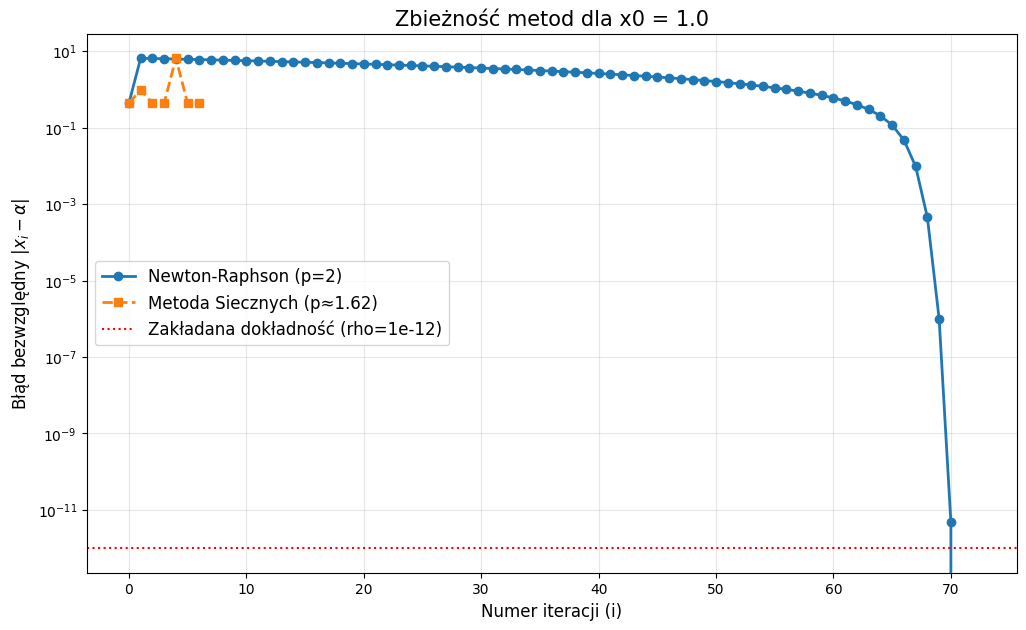

In [13]:
x0_test = 1.0
x1_test = -0.4
stop_criterion = "incremental"
RHO = 1e-12 # Bardzo wysoka dokładność dla ładnego wykresu

_, hist_newton, _ = newton_raphson(x0_test, RHO, stop_criterion)
_, hist_secant, _ = secant_method(x0_test, x1_test, RHO, stop_criterion)

errors_newton = [abs(x - SOLUTION) for x in hist_newton]
errors_secant = [abs(x - SOLUTION) for x in hist_secant]

plt.figure(figsize=(12, 7))

plt.semilogy(range(len(errors_newton)), errors_newton, 'o-', linewidth=2, label='Newton-Raphson (p=2)')
plt.semilogy(range(len(errors_secant)), errors_secant, 's--', linewidth=2, label='Metoda Siecznych (p≈1.62)')

# Linia pomocnicza poziomu SOLUTION (maszynowe zero / rho)
plt.axhline(y=RHO, color='r', linestyle=':', label=f'Zakładana dokładność (rho={RHO})')

plt.title(f'Zbieżność metod dla x0 = {x0_test}', fontsize=15)
plt.xlabel('Numer iteracji (i)', fontsize=12)
plt.ylabel('Błąd bezwzględny $|x_i - \\alpha|$', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend(fontsize=12)

plt.show()